# Data Quality Monitoring System for E-Commerce Operations

## Project Overview

This project presents the development of a Data Quality Monitoring System using the **Olist Brazilian E-Commerce Public Dataset**. The objective is to simulate a real-world business analytics workflow by identifying, assessing, and improving the quality of transactional data before it is used for reporting and decision-making.

The project follows an end-to-end data analytics pipeline, beginning with data preparation in **Python**, followed by data modelling and quality analysis in **PostgreSQL**, and concluding with interactive **Power BI** dashboards that monitor key data quality metrics and business performance indicators.

Throughout the project, data quality dimensions such as **completeness, accuracy, consistency, validity, uniqueness, and timeliness** are evaluated. The datasets are cleaned, standardized, validated, and transformed into analysis-ready data to support reliable business intelligence and operational reporting.

This project demonstrates practical skills in data cleaning, exploratory data analysis, SQL development, data quality assessment, and dashboard development while following industry-standard data analytics practices.

This script focuses on the preparation of the Olist order reviews dataset as part of the Data Quality Monitoring System for E-Commerce Operations. The cleaned dataset supports customer satisfaction and service quality analysis by capturing review scores, customer feedback, review creation dates, and response timestamps associated with completed orders. Preparing this dataset ensures that customer review information is complete, consistent, and reliable for downstream analysis in PostgreSQL, SQL, and Power BI, enabling accurate evaluation of customer sentiment, review trends, and overall service performance.

### Import The Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re 
import psycopg2
from sqlalchemy import create_engine 
from pathlib import Path

### Load The Dataset

In [2]:
order_reviews_df = pd.read_csv(r"C:\Users\Deviare User\OneDrive\Desktop\e-commerce\01_datasets\raw\olist_order_reviews_dataset.csv")

## **ORDER DATASET**

### 1. Data Inspection

In [3]:
# The first five rows of the order reviews dataset
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [4]:
# The number of rows and columns in the order reviews dataset
order_reviews_df.shape

(99224, 7)

In [5]:
#The column names and their data types in the order reviews dataset
order_reviews_df.dtypes

review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object

The order reviews dataset contains seven variables describing customer review information associated with completed orders. The `review_id`, `order_id`, `review_comment_title`, and `review_comment_message` columns are stored as text (`object`), while `review_score` is stored as an integer (`int64`). Both `review_creation_date` and `review_answer_timestamp` are currently stored as text (`object`) and will require conversion to the appropriate datetime data type during data cleaning.

In [6]:
# The number of missing values in each column of the order reviews dataset
order_reviews_df.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

The inspection identified no missing values in the primary identifier fields, review score, or review date variables, indicating that all review records contain the essential information required for analysis. Missing values are present only in the `review_comment_title` and `review_comment_message` columns, with 87,656 and 58,247 missing values respectively.

These fields capture optional written feedback provided by customers. Since customers can submit a review score without providing a title or written comment, the observed missing values represent expected business behaviour rather than data quality issues.

In [7]:
# The number of duplicate rows in the order payments dataset columns
for col in order_reviews_df.columns:
    duplicates = order_reviews_df[col].duplicated().sum()
    print(f"{col}: {duplicates}")

review_id: 814
order_id: 551
review_score: 99219
review_comment_title: 94696
review_comment_message: 63064
review_creation_date: 98588
review_answer_timestamp: 976


The inspection identified duplicate values across several columns, including the review identifiers, order identifiers, review scores, review comment titles, review comment messages, review creation dates, and review response timestamps. These repeated values are expected within transactional datasets because multiple reviews may share the same rating, comment, submission date, or response timestamp.

Duplicate values within individual columns do not necessarily indicate duplicated records. A complete duplicate record assessment will therefore be conducted during the data profiling phase to determine whether identical rows exist within the dataset.

In [8]:
# Statistical summary of the order reviews dataset numeric column
order_reviews_df.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


Reasoning

The numeric summary indicates that the dataset contains **99,224** review records with review scores ranging from **1** to **5**, confirming that all ratings fall within the expected Olist review scale. The average review score is approximately **4.09**, while both the median and upper quartile equal **5**, indicating that most customers assigned high ratings. The standard deviation of approximately **1.35** suggests moderate variation in customer ratings. No review scores fall outside the expected range, and no numerical anomalies requiring further investigation were identified during the inspection stage.

In [9]:
# Statistical summary of the order reviews dataset categorical columns
order_reviews_df.describe(include='object')

,review_id,order_id,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,11568,40977,99224,99224
unique,98410,98673,4527,36159,636,98248
top,7b606b0d57b078384f0b58eac1d41d78,c88b1d1b157a9999ce368f218a407141,Recomendo,Muito bom,2017-12-19 00:00:00,2017-06-15 23:21:05
freq,3,3,423,230,463,4


The categorical summary shows that both the `review_id` and `order_id` columns contain a high number of unique values, which is consistent with transactional review data. The number of unique values is slightly lower than the total record count, indicating that some identifiers appear more than once and should be investigated during the data profiling phase.

The `review_comment_title` and `review_comment_message` columns contain substantially fewer unique values due to the large number of missing values and repeated customer responses. This behaviour is expected because providing written feedback is optional and customers may submit identical comments.

Similarly, the `review_creation_date` and `review_answer_timestamp` columns contain repeated values, reflecting multiple reviews being created or answered on the same dates and times. No unexpected categories or inconsistencies were identified during this inspection stage.

### 2. Data Profiling

#### Duplicated Records

In [10]:
# Count duplicate records
duplicate_count = order_reviews_df.duplicated().sum()

print(f"Duplicate Records: {duplicate_count}")

Duplicate Records: 0


In [11]:
# Display the dimensions of the duplicate records
duplicate_count.shape

()

In [12]:
# Compare original and deduplicated datasets
print(f"Original Records : {len(order_reviews_df):,}")
print(f"Unique Records   : {len(order_reviews_df.drop_duplicates()):,}")
print(f"Duplicate Records: {duplicate_count:,}")

Original Records : 99,224
Unique Records   : 99,224
Duplicate Records: 0


The duplicate record assessment confirmed that the order reviews dataset contains no duplicate records. A total of **99,224** records were examined, with the duplicate count equal to **0**. Additionally, the deduplicated dataset retained all **99,224** records, confirming that no identical observations exist within the dataset. Consequently, no duplicate records require removal, and all records will be retained in the cleaned dataset.

#### Review Identifiers

In [13]:
# Count duplicated review IDs
duplicated_review_ids = (
    order_reviews_df["review_id"]
    .duplicated()
    .sum()
)

print(f"Duplicated Review IDs: {duplicated_review_ids}")

Duplicated Review IDs: 814


In [14]:
# Display duplicated review IDs
duplicated_review_records = order_reviews_df[
    order_reviews_df["review_id"].duplicated(keep=False)
].sort_values("review_id")

duplicated_review_records

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
90677,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
92876,0174caf0ee5964646040cd94e15ac95e,f93a732712407c02dce5dd5088d0f47b,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07 00:00:00,2018-03-08 03:00:53
...,...,...,...,...,...,...,...
31120,fe5c833752953fed3209646f1f63b53c,4863e15fa53273cc7219c58f5ffda4fb,1,NaN,"Comprei dois produtos e ambos, mesmo enviados ...",2018-02-28 00:00:00,2018-02-28 13:57:52
7870,ff2fc9e68f8aabfbe18d710b83aabd30,2da58e0a7dcfa4ce1e00fad9d03ca3b5,2,NaN,NaN,2018-03-17 00:00:00,2018-03-19 11:44:15
82521,ff2fc9e68f8aabfbe18d710b83aabd30,1078d496cc6ab9a8e6f2be77abf5091b,2,NaN,NaN,2018-03-17 00:00:00,2018-03-19 11:44:15
73951,ffb8cff872a625632ac983eb1f88843c,c44883fc2529b4aa03ca90e7e09d95b6,3,NaN,NaN,2017-07-22 00:00:00,2017-07-26 13:41:07


In [15]:
# Number of unique duplicated review IDs
duplicated_review_records["review_id"].nunique()

789

In [16]:
# Frequency of duplicated review IDs
duplicated_review_records["review_id"].value_counts()

review_id
4548534449b1f572e357211b90724f1b    3
2d6ac45f859465b5c185274a1c929637    3
1fb4ddc969e6bea80e38deec00393a6f    3
4d0e6dd087008d1f992d25ef6e1f619f    3
c444278834184f72b1484dfe47de7f97    3
                                   ..
5bdf704ce1edc91bc6c73abede903d1c    2
5c4bd938f98283c5d7145a9d25a89c3e    2
5c99f6ff0f883ea3b283853720266109    2
5ccf9e14796ecb4f98ce11d896e9f0c0    2
ffb8cff872a625632ac983eb1f88843c    2
Name: count, Length: 789, dtype: int64

In [17]:
# Compare duplicated review IDs with associated order IDs
duplicated_review_records[
    ["review_id", "order_id"]
].sort_values(["review_id", "order_id"])

,review_id,order_id
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa
90677,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801
57280,0174caf0ee5964646040cd94e15ac95e,74db91e33b4e1fd865356c89a61abf1f
...,...,...
40378,fe5c833752953fed3209646f1f63b53c,d3775e436e60258e62e678a0f68a0f8d
82521,ff2fc9e68f8aabfbe18d710b83aabd30,1078d496cc6ab9a8e6f2be77abf5091b
7870,ff2fc9e68f8aabfbe18d710b83aabd30,2da58e0a7dcfa4ce1e00fad9d03ca3b5
73951,ffb8cff872a625632ac983eb1f88843c,c44883fc2529b4aa03ca90e7e09d95b6


In [18]:
# Determine whether duplicated review IDs contain identical records
(
    duplicated_review_records
    .groupby("review_id")
    .nunique()
)

,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
review_id,,,,,,
00130cbe1f9d422698c812ed8ded1919,2,1,0,1,1,1
0115633a9c298b6a98bcbe4eee75345f,2,1,0,0,1,1
0174caf0ee5964646040cd94e15ac95e,2,1,0,1,1,1
017808d29fd1f942d97e50184dfb4c13,2,1,0,0,1,1
0254bd905dc677a6078990aad3331a36,2,1,0,1,1,1
...,...,...,...,...,...,...
fde2e6abaf5bb64f7407a44741c24dec,2,1,0,0,1,1
fde5986d35c89aa1b6ce4149de82a0d3,2,1,0,0,1,1
fe5c833752953fed3209646f1f63b53c,2,1,0,1,1,1


In [19]:
# Display one duplicated review ID in full for detailed inspection
sample_review_id = duplicated_review_records["review_id"].iloc[0]

order_reviews_df[
    order_reviews_df["review_id"] == sample_review_id
]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23


In [20]:
duplicated_review_records["review_id"].value_counts().value_counts()

count
2    764
3     25
Name: count, dtype: int64

The investigation identified **814 duplicated review ID** occurrences, representing **789 unique review IDs**. Further analysis revealed that duplicated review IDs are associated with different order IDs, indicating that the same review identifier appears across multiple orders rather than being repeated within the same order.

Inspection of the duplicated records shows that, for each duplicated review ID, the review score, review title, review message, review creation date, and review response timestamp remain identical. The only attribute that varies is the `order_id`. This finding is supported by the uniqueness assessment, which indicates that duplicated review IDs have two unique order IDs while all remaining attributes contain only a single unique value.

Additionally, the frequency analysis shows that most duplicated review IDs occur **twice**, while a small number occur **three times**. Since the duplicated review records are not identical rows and reference different orders, they do not constitute duplicate records. Instead, they represent a characteristic of the source data in which the same customer review has been linked to multiple orders.

The frequency analysis shows that the majority of duplicated review IDs occur **twice**, accounting for **764** review identifiers. Additionally, **25** review identifiers occur **three** times. This indicates that duplicated review IDs are relatively uncommon and are primarily limited to two associated orders, with only a small number linked to three orders.

#### Order Identifiers Frequency

In [21]:
# Identify all review records associated with repeated order IDs

duplicated_order_ids = order_reviews_df[
    order_reviews_df.duplicated(subset="order_id", keep=False)
].sort_values(["order_id", "review_creation_date", "review_answer_timestamp"])

print("Review records with repeated order IDs:", len(duplicated_order_ids))
print(
    "Unique orders with multiple review records:",
    duplicated_order_ids["order_id"].nunique()
)

duplicated_order_ids.head(20)

Review records with repeated order IDs: 1098
Unique orders with multiple review records: 547


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29 00:00:00,2017-08-30 01:59:12
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 12:12:30
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04 00:00:00,2018-03-05 17:02:00
854,830636803620cdf8b6ffaf1b2f6e92b2,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:06
83224,d8e8c42271c8fb67b9dad95d98c8ff80,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:47
89888,0c8e7347f1cdd2aede37371543e3d163,02355020fd0a40a0d56df9f6ff060413,3,NaN,UM DOS PRODUTOS (ENTREGA02) COMPRADOS NESTE PE...,2018-03-21 00:00:00,2018-03-22 01:32:08
17582,017f0e1ea6386de662cbeba299c59ad1,02355020fd0a40a0d56df9f6ff060413,1,NaN,ja reclamei varias vezes e ate hoje não sei on...,2018-03-29 00:00:00,2018-03-30 03:16:19
37911,04d945e95c788a3aa1ffbee42105637b,029863af4b968de1e5d6a82782e662f5,5,NaN,NaN,2017-07-14 00:00:00,2017-07-17 13:58:06
55137,61fe4e7d1ae801bbe169eb67b86c6eda,029863af4b968de1e5d6a82782e662f5,4,NaN,NaN,2017-07-19 00:00:00,2017-07-20 12:06:11


In [22]:
# Examine the number of review records associated with each order

reviews_per_order = (
    order_reviews_df.groupby("order_id")
    .size()
    .sort_values(ascending=False)
)

print("Review count frequency per order:")
print(reviews_per_order.value_counts().sort_index())

print("\nMaximum number of review records for a single order:")
print(reviews_per_order.max())

print("\nOrders with multiple review records:")
print((reviews_per_order > 1).sum())

Review count frequency per order:
1    98126
2      543
3        4
Name: count, dtype: int64

Maximum number of review records for a single order:
3

Orders with multiple review records:
547


In [23]:
# Determine whether repeated orders are associated with different review IDs

repeated_order_review_ids = (
    duplicated_order_ids.groupby("order_id")
    .agg(
        review_records=("review_id", "size"),
        unique_review_ids=("review_id", "nunique")
    )
)

print("Repeated orders where review record count differs from unique review ID count:")
print(
    (
        repeated_order_review_ids["review_records"]
        != repeated_order_review_ids["unique_review_ids"]
    ).sum()
)

print("\nReview record vs unique review ID patterns:")
print(
    repeated_order_review_ids[
        ["review_records", "unique_review_ids"]
    ]
    .value_counts()
    .sort_index()
)

Repeated orders where review record count differs from unique review ID count:
0

Review record vs unique review ID patterns:
review_records  unique_review_ids
2               2                    543
3               3                      4
Name: count, dtype: int64


In [24]:
# Compare review attributes within orders containing multiple review records

review_attribute_variation = (
    duplicated_order_ids.groupby("order_id")
    .agg(
        review_records=("review_id", "size"),
        unique_review_ids=("review_id", "nunique"),
        unique_scores=("review_score", "nunique"),
        unique_titles=("review_comment_title", lambda x: x.nunique(dropna=False)),
        unique_messages=("review_comment_message", lambda x: x.nunique(dropna=False)),
        unique_creation_dates=("review_creation_date", "nunique"),
        unique_answer_timestamps=("review_answer_timestamp", "nunique")
    )
)

print("Attribute variation among orders with multiple reviews:\n")

for column in [
    "unique_review_ids",
    "unique_scores",
    "unique_titles",
    "unique_messages",
    "unique_creation_dates",
    "unique_answer_timestamps"
]:
    print(f"{column}:")
    print(review_attribute_variation[column].value_counts().sort_index())
    print()

Attribute variation among orders with multiple reviews:

unique_review_ids:
unique_review_ids
2    543
3      4
Name: count, dtype: int64

unique_scores:
unique_scores
1    345
2    202
Name: count, dtype: int64

unique_titles:
unique_titles
1    534
2     13
Name: count, dtype: int64

unique_messages:
unique_messages
1    317
2    228
3      2
Name: count, dtype: int64

unique_creation_dates:
unique_creation_dates
1    155
2    390
3      2
Name: count, dtype: int64

unique_answer_timestamps:
unique_answer_timestamps
2    543
3      4
Name: count, dtype: int64



In [25]:
# Determine how many repeated orders contain differences in review content or timing

variation_summary = pd.Series({
    "Different review IDs":
        (review_attribute_variation["unique_review_ids"] > 1).sum(),

    "Different review scores":
        (review_attribute_variation["unique_scores"] > 1).sum(),

    "Different review titles":
        (review_attribute_variation["unique_titles"] > 1).sum(),

    "Different review messages":
        (review_attribute_variation["unique_messages"] > 1).sum(),

    "Different creation dates":
        (review_attribute_variation["unique_creation_dates"] > 1).sum(),

    "Different answer timestamps":
        (review_attribute_variation["unique_answer_timestamps"] > 1).sum()
})

print("Number of repeated orders showing variation:")
print(variation_summary)

Number of repeated orders showing variation:
Different review IDs           547
Different review scores        202
Different review titles         13
Different review messages      230
Different creation dates       392
Different answer timestamps    547
dtype: int64


In [26]:
# Display complete review records for a sample of orders with multiple reviews

sample_repeated_orders = reviews_per_order[
    reviews_per_order > 1
].head(10).index

sample_reviews = (
    order_reviews_df[
        order_reviews_df["order_id"].isin(sample_repeated_orders)
    ]
    .sort_values(["order_id", "review_creation_date", "review_answer_timestamp"])
)

sample_reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
69438,405eb2ea45e1dbe2662541ae5b47e2aa,03c939fd7fd3b38f8485a0f95798f1f6,3,NaN,Seria ótimo se tivesem entregue os 3 (três) pe...,2018-03-06 00:00:00,2018-03-06 19:50:32
8273,b04ed893318da5b863e878cd3d0511df,03c939fd7fd3b38f8485a0f95798f1f6,3,NaN,Um ponto negativo que achei foi a cobrança de ...,2018-03-20 00:00:00,2018-03-21 02:28:23
51527,f4bb9d6dd4fb6dcc2298f0e7b17b8e1e,03c939fd7fd3b38f8485a0f95798f1f6,4,NaN,NaN,2018-03-29 00:00:00,2018-03-30 00:29:09
35206,f1cba0ac840dac58e4b619bd3424f443,29062384ce4975f78aeba6a496510386,1,NaN,Na foto o produto e um e Na hora que o produto...,2018-03-10 00:00:00,2018-03-14 18:21:23
67550,a2a33763a53c33c8f07e58d55855dc77,29062384ce4975f78aeba6a496510386,5,NaN,Bom amei o produto\r\n,2018-03-15 00:00:00,2018-03-15 22:34:26
64155,998db536f6e46f88ce9988d043d8a9b1,4703440eb9289d3769819920e98ec061,5,NaN,NaN,2018-02-15 00:00:00,2018-02-16 01:50:35
1163,771654d19b26b9108952856b225ad105,4703440eb9289d3769819920e98ec061,5,NaN,NaN,2018-02-15 00:00:00,2018-02-16 01:50:41
24262,19194f53840fc6c2857dd8809972a209,82fd1196a459f594fb1d66e667fc74c4,4,NaN,NaN,2018-01-23 00:00:00,2018-01-24 12:43:58
85800,3d163199153af414059e6cfabc09a0fd,82fd1196a459f594fb1d66e667fc74c4,1,NaN,Depois de receber o produto avariado e solicit...,2018-04-21 00:00:00,2018-04-23 14:03:47
53661,308316408775d1600dad81bd3184556d,8b3c2785144e72ccba9b0213f0f1cd1e,5,NaN,Ajudem a rastrear uma das 3 prateleiras que fa...,2017-09-07 00:00:00,2017-09-11 09:58:09


The `order_id` assessment identified **1,098 review records** associated with **547 orders** containing multiple reviews. Of these, **543 orders** contain two review records and **4 orders** contain three, with a maximum of **3 reviews per order**.

All repeated `order_id` values are associated with distinct `review_id` values, with no cases where the number of review records exceeds the number of unique review identifiers. Further comparison showed meaningful variation across the associated reviews: **202 orders** contain different `review_score` values, **13** contain different `review_comment_title` values, **230** contain different `review_comment_message` values, **392** have different `review_creation_date` values, and all **547 orders** have different `review_answer_timestamp` values.

These findings indicate that the repeated `order_id` values represent distinct review observations rather than duplicate records. There is insufficient evidence to identify any individual review as erroneous or to justify selecting, aggregating, or removing reviews during data preparation. Therefore, all review records will be retained without modification. Referential validation of `order_id` against the Orders dataset will be performed later during relational validation in PostgreSQL/SQL.

#### Review Scores Distribution

In [30]:
# Examine the frequency and percentage distribution of review scores

score_counts = (
    order_reviews_df["review_score"]
    .value_counts()
    .sort_index()
)

score_percentages = (
    order_reviews_df["review_score"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

review_score_distribution = pd.DataFrame({
    "count": score_counts,
    "percentage": score_percentages
})

print("Review score distribution:")
print(review_score_distribution)

Review score distribution:
              count  percentage
review_score                   
1             11424       11.51
2              3151        3.18
3              8179        8.24
4             19142       19.29
5             57328       57.78


In [27]:
# Validate review score values

invalid_review_scores = order_reviews_df[
    ~order_reviews_df["review_score"].isin([1, 2, 3, 4, 5])
]

print("Invalid review score records:", len(invalid_review_scores))
print("Missing review scores:", order_reviews_df["review_score"].isna().sum())

print("\nObserved review score values:")
print(sorted(order_reviews_df["review_score"].unique()))

Invalid review score records: 0
Missing review scores: 0

Observed review score values:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


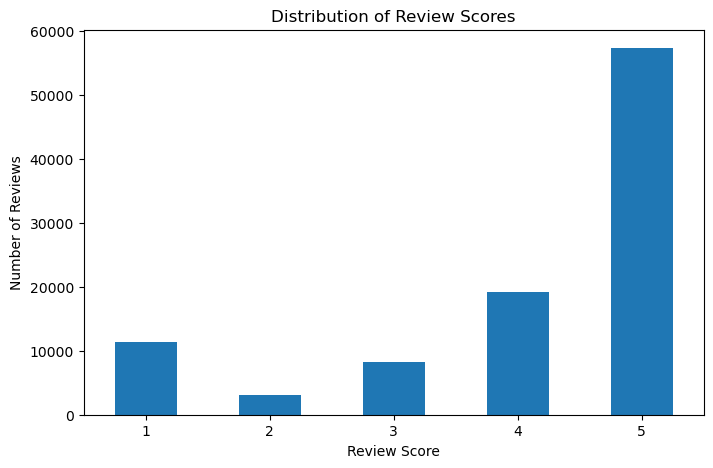

In [28]:
# Visualise the distribution of review scores

score_counts = (
    order_reviews_df["review_score"]
    .value_counts()
    .sort_index()
)

score_counts.plot(
    kind="bar",
    figsize=(8, 5),
    title="Distribution of Review Scores"
)

plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

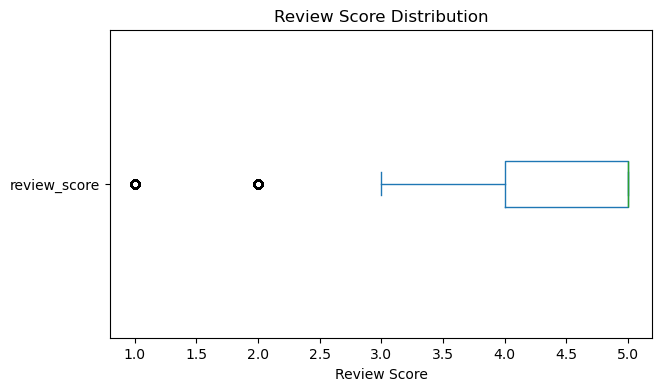

In [29]:
# Examine the spread of review scores

order_reviews_df["review_score"].plot(
    kind="box",
    figsize=(7, 4),
    vert=False,
    title="Review Score Distribution"
)

plt.xlabel("Review Score")
plt.show()

Validation of the `review_score` field confirmed **0 invalid values** and **0 missing values**, with all records containing valid integer ratings within the expected **1–5** scale. The observed review scores consist exclusively of the permitted values **1**, **2**, **3**, **4**, and **5**, indicating no coding inconsistencies or unexpected categories.

The score distribution is heavily weighted toward higher ratings, with **57.78%** of reviews receiving a score of **5** and **19.29%** receiving a score of **4**. Together, ratings of **4** and **5** account for approximately **77%** of all reviews, while lower ratings remain comparatively infrequent. Although the box plot identifies ratings of **1** and **2** as statistical outliers due to the concentration of higher scores, these represent legitimate customer feedback rather than data quality errors.

No cleaning is required. All `review_score` values will be retained without modification for subsequent business analysis.

#### Review Comment Titles

In [31]:
# Examine missingness and basic characteristics of review titles

title_missing = order_reviews_df["review_comment_title"].isna().sum()
title_present = order_reviews_df["review_comment_title"].notna().sum()

print(f"Missing review titles: {title_missing:,}")
print(f"Reviews with titles: {title_present:,}")
print(f"Percentage missing: {title_missing / len(order_reviews_df) * 100:.2f}%")
print(f"Unique non-null titles: {order_reviews_df['review_comment_title'].nunique():,}")

Missing review titles: 87,656
Reviews with titles: 11,568
Percentage missing: 88.34%
Unique non-null titles: 4,527


review_comment_title
Recomendo          423
recomendo          345
Bom                293
super recomendo    270
Excelente          248
Muito bom          247
Ótimo              240
Super recomendo    217
Ótimo              207
Otimo              174
10                 158
Excelente          119
otimo              105
bom                 97
Muito bom           87
Boa                 86
Recomendo           62
Perfeito            57
Ótima               55
Bom                 55
Name: count, dtype: int64


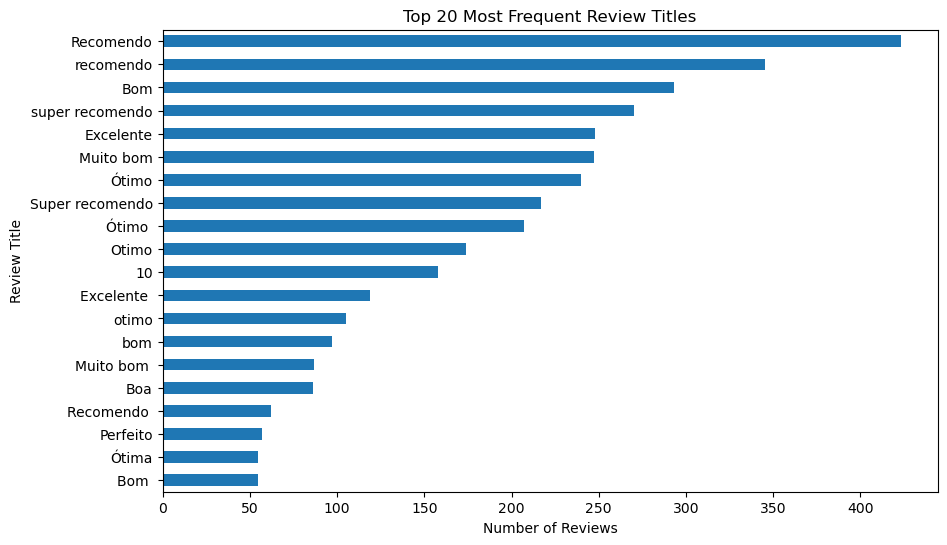

In [32]:
# Examine the distribution of the most common review titles

top_review_titles = (
    order_reviews_df["review_comment_title"]
    .dropna()
    .value_counts()
    .head(20)
)

print(top_review_titles)

plt.figure(figsize=(10, 6))
top_review_titles.sort_values().plot(kind="barh")

plt.title("Top 20 Most Frequent Review Titles")
plt.xlabel("Number of Reviews")
plt.ylabel("Review Title")
plt.show()

In [33]:
# Check for empty or whitespace-only titles

empty_titles = order_reviews_df[
    order_reviews_df["review_comment_title"]
    .fillna("")
    .str.strip()
    .eq("")
    &
    order_reviews_df["review_comment_title"].notna()
]

print("Empty or whitespace-only review titles:", len(empty_titles))

empty_titles.head()

Empty or whitespace-only review titles: 2


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
49962,af070b6f68aef93db14f3af532e6d590,474b7ce14c066d845352314f51725fd4,5,,Produto de fácil instalação. Chegou em 3 dias.,2018-05-10 00:00:00,2018-05-10 23:20:41
93916,10915c6e8a820f34f735c6a739a1b0ec,6903412e8ef5bbc0934881a1059c0942,5,,NaN,2018-08-24 00:00:00,2018-08-25 02:07:20


count    11568.000000
mean        11.945021
std          6.328580
min          1.000000
25%          7.000000
50%         10.000000
75%         16.000000
max         26.000000
Name: review_comment_title, dtype: float64


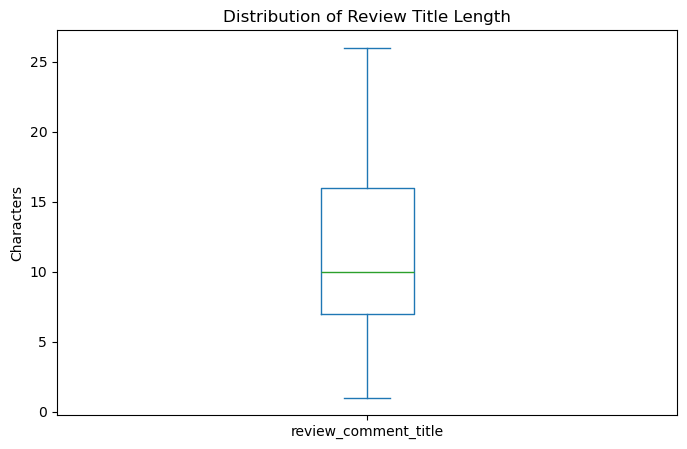

In [34]:
# Examine title length distribution

title_lengths = (
    order_reviews_df["review_comment_title"]
    .dropna()
    .str.len()
)

print(title_lengths.describe())

plt.figure(figsize=(8, 5))
title_lengths.plot(kind="box")

plt.title("Distribution of Review Title Length")
plt.ylabel("Characters")
plt.show()

In [35]:
# Display the shortest and longest review titles for manual inspection

print("Five shortest review titles:")
display(
    order_reviews_df.loc[
        order_reviews_df["review_comment_title"].notna(),
        ["review_comment_title"]
    ]
    .assign(length=lambda df: df["review_comment_title"].str.len())
    .sort_values("length")
    .head(5)
)

print("\nFive longest review titles:")
display(
    order_reviews_df.loc[
        order_reviews_df["review_comment_title"].notna(),
        ["review_comment_title"]
    ]
    .assign(length=lambda df: df["review_comment_title"].str.len())
    .sort_values("length", ascending=False)
    .head(5)
)

Five shortest review titles:


,review_comment_title,length
48646,8,1
51831,+,1
6453,9,1
27205,5,1
11469,7,1



Five longest review titles:


,review_comment_title,length
29986,targaryen 10. lannister 0.,26
35640,chegou antes do prazo!!!,25
84592,Não recebi todos os produ,25
25276,satisfação com o serviço,25
44412,recebi o produto na data,25


##### Text Formatting Consistency

In [36]:
# Compare original titles with lowercase equivalents

title_case_comparison = (
    order_reviews_df["review_comment_title"]
    .dropna()
    .to_frame()
)

title_case_comparison["normalized"] = (
    title_case_comparison["review_comment_title"]
    .str.strip()
    .str.lower()
)

case_variations = (
    title_case_comparison
    .groupby("normalized")["review_comment_title"]
    .nunique()
    .sort_values(ascending=False)
)

print("Normalized titles with multiple formatting variants:")
print((case_variations > 1).sum())

case_variations[case_variations > 1].head(20)

Normalized titles with multiple formatting variants:
496


normalized
super recomendo      10
recomendo            10
muito bom            10
super recomendado     9
otimo                 7
bom                   7
produto errado        7
tudo ok               7
ótimo produto         6
péssimo               6
ótimo                 6
muito bom!            6
não recomendo         6
entrega rápida        6
muito boa             6
muito bom produto     5
atraso na entrega     5
recomendo!            5
não recomendado       5
bom produto           5
Name: review_comment_title, dtype: int64

In [37]:
# Display examples of formatting variants

variant_examples = (
    title_case_comparison
    .groupby("normalized")["review_comment_title"]
    .unique()
)

variant_examples[case_variations > 1].head(20)

normalized
10                                                              [10,  10, 10 ]
100                                                                [100, 100 ]
100%                                                             [100%, 100% ]
4                                                                     [ 4 , 4]
5                                                                      [5, 5 ]
5 estrelas                               [5 estrelas, 5 ESTRELAS,  5 estrelas]
7                                                                      [7, 7 ]
acabamento                                            [acabamento, Acabamento]
acabamento ruim                             [Acabamento Ruim, Acabamento ruim]
adorei                                               [Adorei, Adorei , adorei]
aguardando                                           [Aguardando, Aguardando ]
ainda nao recebi                          [Ainda nao recebi, ainda nao recebi]
ainda nao recebi o produt    [Ainda nao r

The `review_comment_title` assessment confirmed that **87,656 records (88.34%)** contain missing values, while **11,568** records include a review title. As review titles are optional customer feedback, these missing values represent **structural missingness** and will be retained without imputation.

Among the non-null values, **4,527** unique review titles were identified. The observed titles consist primarily of short customer-written phrases with lengths ranging from **1** to **26** characters, showing no evidence of abnormal text lengths or systematic corruption. A formatting consistency assessment identified **496 normalized titles** with capitalization or formatting variations (for example, different uses of upper- and lower-case letters). These variations reflect normal customer writing behaviour rather than data quality issues and will be preserved to maintain the original review content.

The investigation identified **2 whitespace-only `review_comment_title` values** that do not contain meaningful text. These records will be converted to `NaN` to ensure consistent representation of missing textual information. No additional cleaning or text normalization will be performed.

#### Review Comment Messages

In [38]:
# Examine missingness and basic characteristics of review messages

message_missing = order_reviews_df["review_comment_message"].isna().sum()
message_present = order_reviews_df["review_comment_message"].notna().sum()

print(f"Missing review messages: {message_missing:,}")
print(f"Reviews with messages: {message_present:,}")
print(f"Percentage missing: {message_missing / len(order_reviews_df) * 100:.2f}%")
print(f"Unique non-null messages: {order_reviews_df['review_comment_message'].nunique():,}")

Missing review messages: 58,247
Reviews with messages: 40,977
Percentage missing: 58.70%
Unique non-null messages: 36,159


In [39]:
# Check for empty or whitespace-only messages

empty_messages = order_reviews_df[
    order_reviews_df["review_comment_message"]
        .fillna("")
        .str.strip()
        .eq("")
    &
    order_reviews_df["review_comment_message"].notna()
]

print("Empty or whitespace-only review messages:", len(empty_messages))

empty_messages.head()

Empty or whitespace-only review messages: 27


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
10001,007c08c01178c42ff829560cc24dd0d6,d9064a51ed213dcd0cfe59a9039ec458,5,NaN,\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n,2017-11-18 00:00:00,2017-11-19 03:56:17
11339,1fe9d2ee706fb28c431aa5d933245d45,81aa3cffc965f29788470b3e2550da67,5,Ótima,\r\n,2018-05-13 00:00:00,2018-05-13 18:55:32
11798,479455dcf5c7b17c5025011776ac844e,d4c1356b86dcc8a86c603174ba27d9bc,5,NaN,\r\n\r\n,2018-01-18 00:00:00,2018-01-19 11:16:25
11892,1ce11bd2d9c397e0b673035dcc533f5c,7a3f8080c604ded6519cd5b601f690b7,5,NaN,\r\n,2018-05-31 00:00:00,2018-06-02 19:06:46
26041,b905a83cd40f67b08363261fc2d2dadb,cf65e1cf310d6860d96e2efaab1f5d75,5,NaN,\r\n,2017-08-22 00:00:00,2017-08-25 01:08:15


In [41]:
# Display the shortest and longest review messages

print("Five shortest review messages:")

display(
    order_reviews_df.loc[
        order_reviews_df["review_comment_message"].notna(),
        ["review_comment_message"]
    ]
    .assign(length=lambda df: df["review_comment_message"].str.len())
    .sort_values("length")
    .head(5)
)

print("\nFive longest review messages:")

display(
    order_reviews_df.loc[
        order_reviews_df["review_comment_message"].notna(),
        ["review_comment_message"]
    ]
    .assign(length=lambda df: df["review_comment_message"].str.len())
    .sort_values("length", ascending=False)
    .head(5)
)

Five shortest review messages:


,review_comment_message,length
41031,,1
12831,x,1
60298,B,1
37721,?,1
41885,-,1



Five longest review messages:


,review_comment_message,length
1316,"NÃO RECEBI O PRODUTO, O PRODUTO CONSTA COMO EN...",208
10734,Adquiri 2 mochilas pelo site lannister de e pa...,207
7267,Comprei o produto confiando nas lojas lanniste...,206
5223,fiz essa compra pelo baratheon comprei um conj...,205
58896,"Produto entregue antes do prazo, o relógio é o...",204


In [42]:
# Examine the most frequently repeated review messages

top_review_messages = (
    order_reviews_df["review_comment_message"]
    .dropna()
    .value_counts()
    .head(20)
)

print(top_review_messages)

review_comment_message
Muito bom               230
Bom                     189
muito bom               122
bom                     107
Recomendo               100
Otimo                    99
otimo                    96
Ótimo                    77
Ótimo                    74
Ok                       72
Excelente                71
Muito bom                66
recomendo                65
ok                       55
.                        51
Recomendo                50
Boa                      47
Tudo ok                  45
Ótimo produto            44
Não recebi o produto     37
Name: count, dtype: int64


In [43]:
# Compare original messages with lowercase equivalents to identify formatting variants

message_case_comparison = (
    order_reviews_df["review_comment_message"]
    .dropna()
    .to_frame()
)

message_case_comparison["normalized"] = (
    message_case_comparison["review_comment_message"]
    .str.strip()
    .str.lower()
)

message_variations = (
    message_case_comparison
    .groupby("normalized")["review_comment_message"]
    .nunique()
    .sort_values(ascending=False)
)

print("Normalized messages with multiple formatting variants:")
print((message_variations > 1).sum())

message_variations[message_variations > 1].head(20)

Normalized messages with multiple formatting variants:
671


normalized
muito bom                     13
tudo ok                       11
bom                           11
ótimo                         10
excelente                     10
recomendo                      9
bom produto                    8
otima                          8
ok                             8
produto de qualidade           7
entrega antes do prazo         7
ainda não recebi o produto     7
produto excelente              7
gostei muito                   7
produto bom                    7
ótimo produto                  7
super recomendo                7
muito bom.                     7
otimo                          7
ótimo produto.                 7
Name: review_comment_message, dtype: int64

In [44]:
# Display examples of formatting variants

message_variant_examples = (
    message_case_comparison
    .groupby("normalized")["review_comment_message"]
    .unique()
)

message_variant_examples[message_variations > 1].head(20)

normalized
                                       [\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n, \r\...
.                                                                             [., \r\n.]
..                                                                             [.., .. ]
a entrega chegou antes do previsto.    [a entrega chegou antes do previsto., A entreg...
a entrega foi muito rápida             [A entrega foi muito rápida, A entrega foi mui...
a entrega poderia ser mais rápida      [A ENTREGA PODERIA SER MAIS RÁPIDA, A entrega ...
a entrega é muito demorada.            [A entrega é muito demorada. , A entrega é mui...
adorei                                        [Adorei, Adorei , adorei, adorei , ADOREI]
adorei muito                                              [adorei muito , Adorei muito ]
adorei o produto                       [ADOREI O PRODUTO, adorei o produto, Adorei o ...
adorei o produto.                                [Adorei o produto., Adorei o produto. ]
adorei!!! 

The `review_comment_message` assessment confirmed that **58,247 records (58.70%)** contain missing values, while **40,977** records include written customer feedback. As review messages are optional, these missing values represent **structural missingness** and will be retained without imputation.

Among the non-null values, **36,159** unique review messages were identified. Review message lengths range from **1** to **208** characters, with no evidence of systematic text corruption, truncation, or abnormal message lengths. Although some reviews consist of single-character responses, these represent valid customer feedback and will be preserved. The formatting consistency assessment identified **671 normalized messages** with capitalization or formatting variations. These differences reflect normal customer writing behaviour rather than data quality issues and will not be standardized.

The investigation identified **27 whitespace-only `review_comment_message` values** that do not contain meaningful text. These records will be converted to `NaN` to ensure consistent representation of missing textual information. No additional cleaning or normalization of customer-written messages will be performed.

In [45]:
# Validate conversion to datetime

review_creation_dates = pd.to_datetime(
    order_reviews_df["review_creation_date"],
    errors="coerce"
)

print("Invalid review creation dates:", review_creation_dates.isna().sum())
print("Original missing values:", order_reviews_df["review_creation_date"].isna().sum())

print("\nEarliest review creation date:", review_creation_dates.min())
print("Latest review creation date:", review_creation_dates.max())

Invalid review creation dates: 0
Original missing values: 0

Earliest review creation date: 2016-10-02 00:00:00
Latest review creation date: 2018-08-31 00:00:00


In [46]:
# Examine the distribution of review creation dates

review_creation_dates.describe()

count                            99224
mean     2018-01-12 20:49:23.948238336
min                2016-10-02 00:00:00
25%                2017-09-23 00:00:00
50%                2018-02-02 00:00:00
75%                2018-05-16 00:00:00
max                2018-08-31 00:00:00
Name: review_creation_date, dtype: object

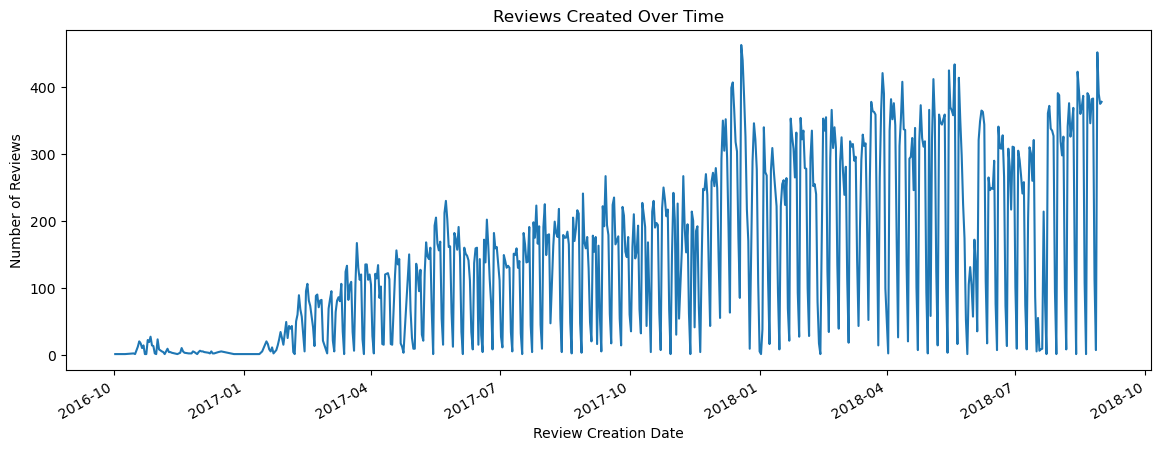

In [47]:
# Visualise review creation dates over time

reviews_by_date = (
    review_creation_dates
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(14,5))

reviews_by_date.plot()

plt.title("Reviews Created Over Time")
plt.xlabel("Review Creation Date")
plt.ylabel("Number of Reviews")
plt.show()

In [48]:
# Check for unusually high numbers of reviews on the same date

daily_review_counts = (
    review_creation_dates
    .value_counts()
    .sort_index()
)

print("Top 10 busiest review dates:")
print(daily_review_counts.sort_values(ascending=False).head(10))

Top 10 busiest review dates:
review_creation_date
2017-12-19    463
2018-08-28    452
2017-12-20    440
2018-05-19    434
2018-05-15    425
2018-08-14    423
2018-03-29    421
2018-05-22    414
2018-05-04    412
2018-04-12    408
Name: count, dtype: int64


In [49]:
# Check for future review creation dates

today = pd.Timestamp.today().normalize()

future_reviews = order_reviews_df[
    review_creation_dates > today
]

print("Future review creation dates:", len(future_reviews))

future_reviews.head()

Future review creation dates: 0


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp


Validation of the `review_creation_date` field confirmed **0 invalid dates**, **0 missing values**, and **0 future dates**. All values can be successfully converted from `object` to the `datetime64[ns]` data type without data loss.

The review creation dates span from **2016-10-02** to **2018-08-31**, providing complete temporal coverage across the period represented in the dataset. Review activity increases progressively throughout the observation period, and although some individual dates contain comparatively high review volumes, these occur across multiple months and are consistent with normal fluctuations in customer activity rather than data quality issues.

No evidence of invalid, implausible, or anomalous dates was identified. The only required transformation is conversion of `review_creation_date` to the appropriate datetime data type during the cleaning phase.

#### Review Answer Timestamp / Chronology

In [50]:
# Validate conversion to datetime

review_answer_timestamps = pd.to_datetime(
    order_reviews_df["review_answer_timestamp"],
    errors="coerce"
)

print("Invalid review answer timestamps:", review_answer_timestamps.isna().sum())
print("Original missing values:", order_reviews_df["review_answer_timestamp"].isna().sum())

print("\nEarliest review answer timestamp:", review_answer_timestamps.min())
print("Latest review answer timestamp:", review_answer_timestamps.max())

Invalid review answer timestamps: 0
Original missing values: 0

Earliest review answer timestamp: 2016-10-07 18:32:28
Latest review answer timestamp: 2018-10-29 12:27:35


In [51]:
# Check whether any responses occurred before the review was created

review_creation_dates = pd.to_datetime(
    order_reviews_df["review_creation_date"],
    errors="coerce"
)

responses_before_creation = order_reviews_df[
    review_answer_timestamps < review_creation_dates
]

print("Responses before review creation:", len(responses_before_creation))

responses_before_creation.head()

Responses before review creation: 0


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp


In [52]:
# Calculate the time between review creation and review response

response_time = (
    review_answer_timestamps - review_creation_dates
)

print(response_time.describe())

count                        99224
mean     3 days 03:34:33.029700475
std      9 days 21:21:40.258026234
min                0 days 02:08:29
25%         1 days 00:07:00.750000
50%         1 days 16:11:55.500000
75%                3 days 02:29:08
max              518 days 16:46:52
dtype: object


In [53]:
# Check for negative response times

negative_response_times = order_reviews_df[
    response_time < pd.Timedelta(0)
]

print("Negative response times:", len(negative_response_times))

negative_response_times.head()

Negative response times: 0


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp


Validation of the `review_answer_timestamp` field confirmed **0 invalid timestamps** and **0 missing values**, indicating that all values can be successfully converted from `object` to the `datetime64[ns]` data type without data loss.

Chronological validation identified **0 responses occurring before their corresponding `review_creation_date`** and **0 negative response intervals**, confirming that the temporal sequence of review creation and review response is internally consistent. Response times range from **2 hours, 8 minutes, 29 seconds** to **518 days, 16 hours, 46 minutes, 52 seconds**. Although some responses occur after extended periods, these represent plausible operational behaviour rather than data quality issues.

No cleaning beyond datatype conversion is required. The `review_answer_timestamp` field will be retained without modification.

### 3. Data Cleaning

#### Review Comment Titles

During the profiling phase, **2 `review_comment_title` values** were identified as containing only whitespace characters. These records do not represent meaningful customer feedback and will be converted to **missing values (`NaN`)** to ensure consistent representation of missing review titles. No other review titles will be modified, preserving the original customer-written content.

In [54]:
# Convert whitespace-only review titles to missing values (NaN)

title_whitespace_mask = (
    order_reviews_df["review_comment_title"].notna()
    & order_reviews_df["review_comment_title"].str.strip().eq("")
)

order_reviews_df.loc[
    title_whitespace_mask,
    "review_comment_title"
] = np.nan

In [55]:
# Validate review comment title cleaning

remaining_whitespace_titles = (
    order_reviews_df["review_comment_title"]
    .dropna()
    .str.strip()
    .eq("")
    .sum()
)

missing_titles = order_reviews_df["review_comment_title"].isna().sum()

print(f"Whitespace-only review titles remaining: {remaining_whitespace_titles}")
print(f"Missing review titles: {missing_titles:,}")
print(f"Dataset shape: {order_reviews_df.shape}")

Whitespace-only review titles remaining: 0
Missing review titles: 87,658
Dataset shape: (99224, 7)


The **2 whitespace-only `review_comment_title` values** were converted to **`NaN`** to ensure consistent representation of missing textual information. No other review titles were modified, preserving the original customer-written content, including capitalization, punctuation, accents, and spelling. The dataset structure and record count remained unchanged.

#### Review Comment Messages

During the profiling phase, **27 `review_comment_message` values** were identified as containing only whitespace characters. These records do not represent meaningful customer feedback and will be converted to **missing values (`NaN`)** to ensure consistent representation of missing review messages. No other review messages will be modified, preserving the original customer-written content.

In [56]:
# Convert whitespace-only review messages to missing values (NaN)

message_whitespace_mask = (
    order_reviews_df["review_comment_message"].notna()
    & order_reviews_df["review_comment_message"].str.strip().eq("")
)

order_reviews_df.loc[
    message_whitespace_mask,
    "review_comment_message"
] = np.nan

In [57]:
# Validate review comment message cleaning

remaining_whitespace_messages = (
    order_reviews_df["review_comment_message"]
    .dropna()
    .str.strip()
    .eq("")
    .sum()
)

missing_messages = order_reviews_df["review_comment_message"].isna().sum()

print(f"Whitespace-only review messages remaining: {remaining_whitespace_messages}")
print(f"Missing review messages: {missing_messages:,}")
print(f"Dataset shape: {order_reviews_df.shape}")

Whitespace-only review messages remaining: 0
Missing review messages: 58,274
Dataset shape: (99224, 7)


The **27 whitespace-only `review_comment_message` values** were converted to **`NaN`** to ensure consistent representation of missing textual information. No other review messages were modified, preserving the original customer-written content, including capitalization, punctuation, accents, and spelling. The dataset structure and record count remained unchanged.

#### Converting `review_creation_date` to Datetime

During the profiling phase, the `review_creation_date` column was successfully validated with **0 invalid dates**, **0 missing values**, and **0 future dates**. Since all values represent valid dates, the column will be converted from the **`object`** data type to **`datetime64[ns]`** to support accurate temporal analysis in the subsequent SQL and Power BI phases.

In [58]:
# Convert review creation date to datetime

order_reviews_df["review_creation_date"] = pd.to_datetime(
    order_reviews_df["review_creation_date"]
)

In [59]:
# Validate review creation date conversion

print(f"Data type: {order_reviews_df['review_creation_date'].dtype}")
print(f"Missing values: {order_reviews_df['review_creation_date'].isna().sum()}")
print(f"Earliest date: {order_reviews_df['review_creation_date'].min()}")
print(f"Latest date: {order_reviews_df['review_creation_date'].max()}")
print(f"Dataset shape: {order_reviews_df.shape}")

Data type: datetime64[ns]
Missing values: 0
Earliest date: 2016-10-02 00:00:00
Latest date: 2018-08-31 00:00:00
Dataset shape: (99224, 7)


The `review_creation_date` column was converted from **`object`** to **`datetime64[ns]`**. Profiling confirmed that all values were valid dates with no missing or future records, allowing the conversion to be completed without data loss. The dataset structure and record count remained unchanged.

#### Converting `review_answer_timestamp` to Datetime

During the profiling phase, the `review_answer_timestamp` column was successfully validated with **0 invalid timestamps**, **0 missing values**, and **0 chronological inconsistencies**. Since all values represent valid timestamps, the column will be converted from the **`object`** data type to **`datetime64[ns]`** to support accurate temporal analysis and preserve the integrity of review response information.

In [60]:
# Convert review answer timestamp to datetime

order_reviews_df["review_answer_timestamp"] = pd.to_datetime(
    order_reviews_df["review_answer_timestamp"]
)

In [61]:
# Validate review answer timestamp conversion

print(f"Data type: {order_reviews_df['review_answer_timestamp'].dtype}")
print(f"Missing values: {order_reviews_df['review_answer_timestamp'].isna().sum()}")
print(f"Earliest timestamp: {order_reviews_df['review_answer_timestamp'].min()}")
print(f"Latest timestamp: {order_reviews_df['review_answer_timestamp'].max()}")
print(f"Dataset shape: {order_reviews_df.shape}")

Data type: datetime64[ns]
Missing values: 0
Earliest timestamp: 2016-10-07 18:32:28
Latest timestamp: 2018-10-29 12:27:35
Dataset shape: (99224, 7)


The `review_answer_timestamp` column was converted from **`object`** to **`datetime64[ns]`**. Profiling confirmed that all timestamps were valid, with no missing values or chronological inconsistencies, allowing the conversion to be completed without data loss. The dataset structure and record count remained unchanged.

#### Final Data Validation

In [65]:
# Display the final dataset dimensions
print(f"Final dataset shape: {order_reviews_df.shape}")

# Check for missing values
missing_values = order_reviews_df.isnull().sum()
print(missing_values)

# Verify duplicate records
print(
    f"Remaining duplicate records: {order_reviews_df.duplicated().sum()}"
)

# Verify review score values
invalid_review_scores = order_reviews_df[
    ~order_reviews_df["review_score"].isin([1, 2, 3, 4, 5])
]

print(f"Invalid review scores: {len(invalid_review_scores)}")

# Verify whitespace-only review titles
remaining_whitespace_titles = order_reviews_df[
    order_reviews_df["review_comment_title"]
    .fillna("")
    .str.strip()
    .eq("")
    &
    order_reviews_df["review_comment_title"].notna()
]

print(
    f"Whitespace-only review titles: "
    f"{len(remaining_whitespace_titles)}"
)

# Verify whitespace-only review messages
remaining_whitespace_messages = order_reviews_df[
    order_reviews_df["review_comment_message"]
    .fillna("")
    .str.strip()
    .eq("")
    &
    order_reviews_df["review_comment_message"].notna()
]

print(
    f"Whitespace-only review messages: "
    f"{len(remaining_whitespace_messages)}"
)

# Verify chronology
responses_before_creation = order_reviews_df[
    order_reviews_df["review_answer_timestamp"]
    < order_reviews_df["review_creation_date"]
]

print(
    f"Responses before review creation: "
    f"{len(responses_before_creation)}"
)

order_reviews_df.info()

Final dataset shape: (99224, 7)
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87658
review_comment_message     58274
review_creation_date           0
review_answer_timestamp        0
dtype: int64
Remaining duplicate records: 0
Invalid review scores: 0
Whitespace-only review titles: 0
Whitespace-only review messages: 0
Responses before review creation: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11566 non-null  object        
 4   review_comment_message   40950 non-null  object        
 5   review_creation_date    

### 4. Export The cleaned Dataset

In [66]:
PROJECT_ROOT = Path(r"C:\Users\Deviare User\OneDrive\Desktop\e-commerce")

RAW_DATA_PATH = PROJECT_ROOT / "01_datasets" / "raw"
CLEANED_DATA_PATH = PROJECT_ROOT / "01_datasets" / "cleaned"

In [67]:
order_reviews_df.to_csv(
    CLEANED_DATA_PATH / "olist_order_reviews_cleaned.csv",
    index=False
)